# Mass-Radius Categorisation
Determine the mass-radius thresholds to divide the sample into Jovian and non-Jovian pairs. Further divisions can be made by detection method, i.e. RV versus Transit + TTVs samples. 

In [1]:
import os
import sys
currdir = os.getcwd()
datadir = lambda file: f'{currdir}/data/{file}'
savedir = lambda file: f'{currdir}/figures/{file}'
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import percentileofscore

sys.path.insert(0, currdir)
import functionalities.general as gen
import functionalities.pairstats as pair

In [2]:
allcat = pd.read_csv(datadir('exoarch2026.07.10.csv'), skiprows=292, low_memory=False)
trunccols = pair.getExoCols(datadir('usefulcols.txt'))
cat = allcat.loc[allcat.default_flag == 1, trunccols]

Mura, Msat = 14.536*gen.MEMJ, 95.159*gen.MEMJ
Rura, Rsat = 4.007*gen.RERJ, 9.1402*gen.RERJ
mpln, masses, siniflag = pair.getmass(cat)
# mpln, masses = allmpln[siniflag == 0], allmasses[siniflag == 0]
rpln, rads = pair.getrad(cat)

discdfs = []
for i, siniF in enumerate([0, 1]):
    df = cat[np.isin(cat.pl_name, mpln[siniflag == siniF])]
    cols, counts = np.unique(df.discoverymethod, return_counts=True)
    discdfs.append(pd.DataFrame(data=[counts], columns=cols, index=[f'{bool(siniF)} sin(i): {np.sum(counts)}']))
pd.concat(discdfs)

,Astrometry,Disk Kinematics,Eclipse Timing Variations,Imaging,Microlensing,Orbital Brightness Modulation,Pulsar Timing,Radial Velocity,Transit,Transit Timing Variations,Pulsation Timing Variations
False sin(i): 2159,6.0,1.0,8,94.0,281.0,3,6,256,1470,34,NaN
True sin(i): 958,NaN,NaN,9,NaN,NaN,3,2,935,6,1,2.0


## Determine the mass & radius thresholds
If we shift to inspect the bounds between Uranus and Saturn, we fit a cubic function between the mass and radius distribution -- cubic because we expect one saddle point between Uranus and Saturn to denote the Jovian threshold. We further note that because of the sin(i) factor, we compile a clean sample of masses rather than the mixed sample of masses and mass*sin(i). The former gives us the mass bound of 0.12 Jupiter masses. For the radius, the radius bound comes out to approximately 0.68 Jupiter radii.

In [3]:
cubic = lambda x, a, b, c, d: a*x**3 + b*x**2 + c*x + d
quintic = lambda x, a, b, c, d, e, f: a*x**5 + b*x**4 + c*x**3 + d*x**2 + e*x + f
quinderive = lambda a, b, c, d: [20*a, 12*b, 6*c, 2*d]
septic =  lambda x, a, b, c, d, e, f, g, h: a*x**7 + \
          b*x**6 + c*x**5 + d*x**4 + e*x**3 + f*x**2 + g*x + h
sepderive = lambda a, b, c, d, e, f: [7*6*a, 6*5*b, 5*4*c, 4*3*d, 3*2*e, 2*f]

def getCDF(data, ends=None):
    '''
    ends (tuple or None): if tuple, then mask out for only the threshold values.
    '''
    if ends is not None:
        m = np.logical_and(data >= ends[0], data <= ends[1])
        d = data[m]
        print(f'The fraction of points preserved is {np.sum(m)} of {len(data)}.')
        
    return [percentileofscore(d, x, kind='strict')/100 for x in d], d

def fitfunc(data, func, ends=None, returnall=False):
    '''
    If we are considering the whole dataset, we remove extreme outliers; 
    functionality can be switched by ends = (np.min(data), np.max(data))
    '''
    if ends is None:
        sig = np.std(np.log10(data))
        median = np.median(np.log10(data))
        ends = (10**(median-3*sig), 10**(median+3*sig))
    
    cdf, data = getCDF(data, ends=ends)
    pars, covar = curve_fit(func, np.log10(data), cdf)
    x = np.logspace(np.log10(ends[0]), np.log10(ends[1]), 10**3)
    
    if not returnall: return pars, x, func(np.log10(x), *pars)
    return pars, (x, func(np.log10(x), *pars)), (data, cdf)
    
def thresholdplots(ax, data, func, skwargs, lkwargs, ends=None, scatter=True):
    '''
    '''
    pars, fitplot, dataplot = fitfunc(data, func, ends=ends, returnall=True)
    if scatter: ax.scatter(*dataplot, **skwargs)
    ylims = ax.get_ylim()
    xticks = np.logspace(*np.log10([np.min(fitplot[0]), np.max(fitplot[0])]), 5)
    ax.set_xticks([], minor=True)
    ax.set_xticks(xticks, gen.formatSig(xticks, 2), minor=False)
    ax.plot(*fitplot, **lkwargs)
    ax.set_ylim(*ylims)

    return pars, ax

The fraction of points preserved is 348 of 2159.
The fraction of points preserved is 480 of 3117.
The fraction of points preserved is 370 of 4721.


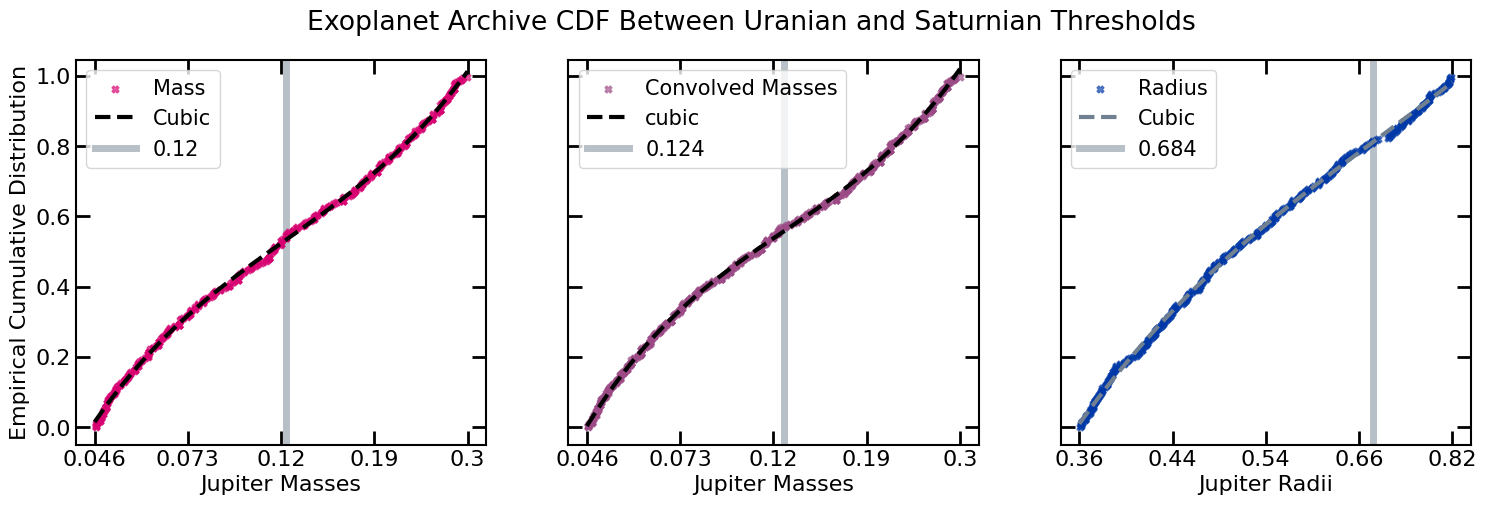

In [4]:
sargs = lambda colour, label: dict(alpha=0.6, color=colour, \
                                marker='X', s=25, label=label)
largs = lambda colour, label: dict(lw=3, ls='dashed', \
                                color=colour, label=label)

fig, axs = gen.setupPlots((18, 5), col=3, sharey=True, logscale=2)
mpars, axs[0] = thresholdplots(axs[0], masses[siniflag == 0], cubic, \
            ends=(Mura, Msat), skwargs=sargs('#d70171', 'Mass'), lkwargs=largs('black', 'Cubic'))
allmpars, axs[1] = thresholdplots(axs[1], masses, cubic, ends=(Mura, Msat), \
            skwargs=sargs('#9b4a85', 'Convolved Masses'), lkwargs=largs('black', 'cubic'))

rpars, axs[2] = thresholdplots(axs[2], rads, cubic, ends=(Rura, Rsat), \
                skwargs=sargs('#0038a7', 'Radius'), lkwargs=largs('slategrey', 'Cubic'))

for i, pars in enumerate([mpars, allmpars, rpars]):
    a, b, c, d = pars
    threshold = 10**(-b/(3*a))
    axs[i].axvline(x=threshold, color='slategrey', lw=5, alpha=0.5, zorder=0, \
                  label=f'{np.round(threshold, 3)}')
    if i == 2: axs[i].set_xlabel('Jupiter Radii')
    else: axs[i].set_xlabel('Jupiter Masses')
    axs[i].legend(fontsize=15)
    
axs[0].set_ylabel('Empirical Cumulative Distribution', fontsize=16)
fig.suptitle('Exoplanet Archive CDF Between Uranian and Saturnian Thresholds')
# fig.savefig(savedir('Exoplanet Archive CDF Between Uranian and Saturnian Thresholds.png'), dpi=500)
fig.show()

For verification, we inspect the entire mass/radius sample. We fit the sample with a quintic and a septic polynomial to see if there are valid saddle points approximately where we expect the Jovian thresholds to be. However, the positive saddle points appear to be larger than the thresholds around 0.1 Jupiter masses.

The fraction of points preserved is 2157 of 2159.
The fraction of points preserved is 2157 of 2159.
The fraction of points preserved is 3115 of 3117.
The fraction of points preserved is 3115 of 3117.
The fraction of points preserved is 4717 of 4721.
The fraction of points preserved is 4717 of 4721.


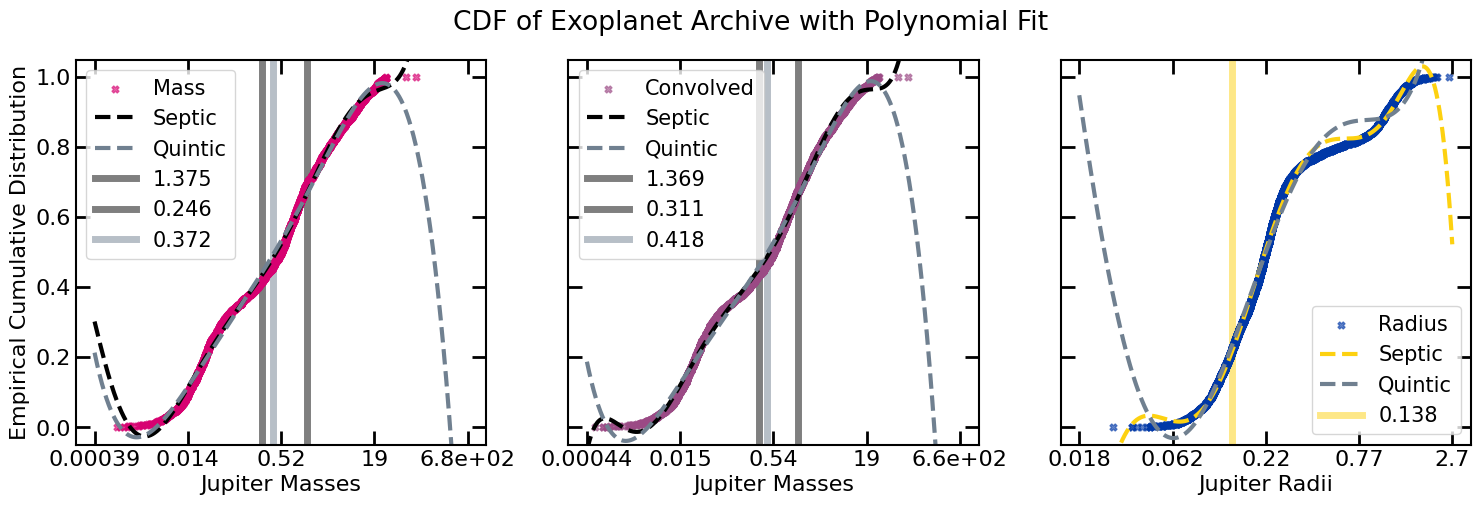

In [5]:
fig, axs = gen.setupPlots((18, 5), col=3, sharey=True, logscale=2)

m7, axs[0] = thresholdplots(axs[0], masses[siniflag == 0], septic, ends=None, \
            skwargs=sargs('#d70171', 'Mass'), lkwargs=largs('black', 'Septic'))
m5, axs[0] = thresholdplots(axs[0], masses[siniflag == 0], quintic, scatter=False, \
            ends=None, skwargs={}, lkwargs=largs('slategrey', 'Quintic'))
am7, axs[1] = thresholdplots(axs[1], masses, septic, ends=None, \
                   skwargs=sargs('#9b4a85', 'Convolved'), lkwargs=largs('black', 'Septic'))
am5, axs[1] = thresholdplots(axs[1], masses, quintic, scatter=False, \
                   ends=None, skwargs={}, lkwargs=largs('slategrey', 'Quintic'))                                  
r7, axs[2] = thresholdplots(axs[2], rads, septic, ends=None, \
                skwargs=sargs('#0038a7', 'Radius'), lkwargs=largs('#fdd110', 'Septic'))
r5, axs[2] = thresholdplots(axs[2], rads, quintic, ends=None, scatter=False, \
                skwargs=sargs('#0038a7', 'Radius'), lkwargs=largs('slategrey', 'Quintic'))


pars = [[m7, m5], [am7, am5], [r7, r5]]

for i, ax in enumerate(axs):
    roots7 = np.roots(sepderive(*pars[i][0][:-2]))
    roots5 = np.roots(quinderive(*pars[i][1][:-2]))
    xlim = ax.get_xlim()

    roots7 = roots7[np.logical_and(roots7 > xlim[0], roots7 < xlim[1])]
    roots5 = roots5[np.logical_and(roots5 > xlim[0], roots5 < xlim[1])]

    for root7 in roots7:
        if i == 2: colour = '#fdd110'
        else: colour = 'black'

        ax.axvline(x=root7, color=colour, lw=5, alpha=0.5, zorder=0, \
                  label=f'{np.round(root7, 3)}')
    for root5 in roots5:
        ax.axvline(x=root5, color='slategrey', lw=5, alpha=0.5, zorder=0, \
                  label=f'{np.round(root5, 3)}')

    if i == 2: ax.set_xlabel('Jupiter Radii')
    else: ax.set_xlabel('Jupiter Masses')
    ax.legend(fontsize=15) #, loc='upper left', framealpha=0.2, edgecolor='0.8')
    
axs[0].set_ylabel('Empirical Cumulative Distribution', fontsize=16)
fig.suptitle('CDF of Exoplanet Archive with Polynomial Fit')
# fig.savefig(savedir('CDF of Exoplanet Archive with Polynomial Fit.png'), dpi=500)
fig.show()

## Jovian versus non-Jovian
With the mass and radius thresholds determined, we define the non-Jovian and Jovian samples. We further subdivide the sample into those discovered by RV and those discovered by Transits + TTVs (defined within the first notebook); we find those that are near first-order and those that are near second order. This is along the lines of Dai et al. 2024. 

For our subsequent work, we are interested in the near first-order Jovian pairs, so we filter for these! Note because of our categorisation of Jovian and non-Jovian is based on mass or radius if both are not available. If both are available:
- Superpuff: the radius is greater than the Jovian threshold but the mass is not.
- Superdense: the mass is above the Jovian threshold but the mass is not. By inspection, we see that this sample is transit-based and the mass approximation is the upper bound. Therefore, we remove this superdense sample from our Jovian sample as their masses are unphysical.

In [6]:
rvcat = pd.read_csv(datadir('rv-catalogue.csv'))
comcat = pd.read_csv(datadir('rv-transit-catalogue.csv'))
transcat = pd.read_csv(datadir('transit(dai2024)catalogue.csv'))

catepars = dict(returnmissing=True, verbose=True)
rvrow, rvcate = pair.planetparstats(rvcat, returndf=True, **catepars)
comrow, comcate = pair.planetparstats(comcat, returndf=True, **catepars)
transrow, transcate = pair.planetparstats(transcat, returndf=True, **catepars)

pd.DataFrame([comrow, transrow, rvrow], index=['Combined', 'Transit + TTV', 'RV'])

There are 38 available radii and 571 masses with an overlap of 36 entries; merged dataframe has 573 planets.
2 planets without mass/radius: GJ 667 C b, HD 160691 d!
There are 1919 available radii and 1241 masses with an overlap of 586 entries; merged dataframe has 2574 planets.
7 planets without mass/radius: GJ 667 C b, HD 160691 d, Kepler-37 e, Kepler-415 c, Kepler-416 c, Kepler-417 c, TOI-1634 c!
There are 1823 available radii and 551 masses with an overlap of 492 entries; merged dataframe has 1882 planets.
4 planets without mass/radius: Kepler-37 e, Kepler-415 c, Kepler-416 c, Kepler-417 c!


,Periods,Masses,Sin(i) Flag,Radius,Jovian by Mass,Jovian by Radius,Non-Jovian by Both,Superpuff,Superdense,Jovian by Both
Combined,2579/2581,1241/2581,506/1241,1919/2581,460,88,474/586,11/586,40/586,61/586
Transit + TTV,1886/1886,551/1886,18/551,1823/1886,110,68,403/492,10/492,37/492,42/492
RV,573/575,571/575,440/571,38/575,295,3,33/36,0/36,0/36,3/36


In [7]:
mdict = {'pairname': 'pl_name', 'joveflag': 'joveflag', 'pairtype':'planettype'}
applyfunc = lambda sys: pair.sysMMRdf(sys, mdict)
jm = lambda df, notjovem: np.logical_and(df.joveflag == '1-1', ~np.isin(df.pairtype, notjovem))
commr = comcate.groupby(['hostname'])[comcate.columns].apply(applyfunc)
rvmmr = rvcate.groupby(['hostname'])[rvcate.columns].apply(applyfunc)
transmmr = transcate.groupby(['hostname'])[transcate.columns].apply(applyfunc)

titlelabels = ['Combined', 'RV', 'Transit + TTVs']
mmrdfs = [commr, rvmmr, transmmr]
pairtypes = np.unique(mmrdfs[0].pairtype)
densepairs = [pt for pt in pairtypes if 'Superdense' in pt]
puffpairs = [pt for pt in pairtypes if 'Superpuff' in pt]
jovecheck = np.append(densepairs, puffpairs)

mmrstatdfs = []
for i, mmrdf in enumerate(mmrdfs):
    
    allrow, _ = pair.mmrStats(mmrdf, verbose=False)
    jovianrow, _ = pair.mmrStats(mmrdf[jm(mmrdf, jovecheck)], verbose=False)    
    nonjov, _ = pair.mmrStats(mmrdf[mmrdf.joveflag == '0-0'], verbose=False)
    df = pd.DataFrame([allrow, jovianrow, nonjov], index=['All', 'Jovian', 'Non-Jovian'])
    mmrstatdfs.append(df)

pd.concat(mmrstatdfs, names=titlelabels)

Because both 55 Cnc-55 Cnc B are within the DataFrame, the number of systems is not interchangeable with the number of planet-hosting stars.
There are the other columns Index(['joveflag', 'pairtype'], dtype='object'), for which 0 rows have nan value in them.
There are the other columns Index(['joveflag', 'pairtype'], dtype='object'), for which 0 rows have nan value in them.
Because both 55 Cnc-55 Cnc B are within the DataFrame, the number of systems is not interchangeable with the number of planet-hosting stars.
There are the other columns Index(['joveflag', 'pairtype'], dtype='object'), for which 0 rows have nan value in them.
There are the other columns Index(['joveflag', 'pairtype'], dtype='object'), for which 0 rows have nan value in them.


,Pairs,Host Stars,Systems,1st Order,2nd Order,Overlap 1st Order,Overlap 2nd Order,MMR Host Stars,MMR Systems,Multi-Resonant Stars,Multi-Resonant Systems,Multi-Resonant Pairs,>= 2 Pair Host Stars,Nan Values,Nan Delta,Mismatch Planet Count,Nan Periods
All,1552.0,1027.0,1026.0,220.0,85.0,224.0,85.0,233.0,233.0,46.0,46.0,155.0,341.0,1.0,1.0,12.0,1.0
Jovian,175.0,158.0,158.0,15.0,8.0,15.0,8.0,23.0,23.0,0.0,0.0,0.0,15.0,1.0,1.0,6.0,1.0
Non-Jovian,1202.0,777.0,777.0,182.0,76.0,186.0,76.0,191.0,191.0,41.0,41.0,138.0,279.0,0.0,NaN,NaN,NaN
All,346.0,227.0,226.0,26.0,13.0,26.0,13.0,34.0,34.0,4.0,4.0,12.0,77.0,1.0,1.0,11.0,1.0
Jovian,136.0,119.0,119.0,11.0,7.0,11.0,7.0,18.0,18.0,0.0,0.0,0.0,15.0,1.0,1.0,6.0,1.0
Non-Jovian,155.0,85.0,85.0,14.0,6.0,14.0,6.0,16.0,16.0,3.0,3.0,9.0,48.0,0.0,NaN,NaN,NaN
All,1150.0,736.0,736.0,197.0,71.0,201.0,71.0,201.0,201.0,42.0,42.0,143.0,265.0,0.0,NaN,NaN,NaN
Jovian,22.0,22.0,22.0,4.0,0.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
Non-Jovian,1023.0,667.0,667.0,171.0,70.0,175.0,70.0,178.0,178.0,38.0,38.0,129.0,231.0,0.0,NaN,NaN,NaN


In [8]:
def formatpairnames(pn):
    splpn = pn.split('-')
    if len(splpn) == 2: return splpn
    halflen = int(len(splpn)//2)
    return ['-'.join(splpn[:halflen]), '-'.join(splpn[halflen:])]

def getplanetpairdf(sysrow, catedf=comcate):
    '''
    '''
    pairname = [formatpairnames(pn) for pn in sysrow.pairname]
    grabcols = ['pl_name', 'sy_pnum', 'discoverymethod', 'pl_orbper', \
                'radius', 'mass', 'siniflag', 'planettype', 'joveflag']
    df = (catedf.copy()).loc[np.isin(catedf.pl_name, *pairname), grabcols]
    df['firstdelta'] = np.array(sysrow.firstdelta)[0]
    if 'reference' in sysrow.columns: df['reference'] = np.array(sysrow.reference)[0]
    return df
        

_, _ = pair.mmrStats(commr, verbose=True)
comm1, comm2 = pair.mmrmasks(commr)
m = np.all([comm1, commr.joveflag == '1-1', commr.firstMMR == '2:1'], axis=0)
references = ['Moutou et al. 2023', None, None, None, 'Wittenmyer et al. 2014', \
              'Tan et al. 2013', None, 'Nabbie et al. 2025', None, None, \
              'Borsato 2019', None, 'Dawson et al. 2021', 'Vítková et al. 2025', None]
two2onedf = commr.copy()[m]
two2onedf['reference'] = references
two2onedf = two2onedf.reset_index(drop=True)
two2one = (two2onedf.groupby(by='hostname')[two2onedf.columns]).apply(getplanetpairdf)
two2one = two2one.reset_index(level=1, drop=True)
# two2one.to_csv('two2onebyplanets.csv')
two2one

Because both 55 Cnc-55 Cnc B are within the DataFrame, the number of systems is not interchangeable with the number of planet-hosting stars.
1552 possible pairs catalogued 1027 planet-hosting stars within 1026 systems. If overlapping, 224 first-order versus 220 first-order; 85 second-order to 85 respectively. Such resonant pairs are hosted by 233 stars within 233 systems. For multi-resonant systems: 46 stars host >= 2 MMR pairs in 46 systems with 155 total pairs. The # stars with >= 2 pairs is 341.
There are the other columns Index(['joveflag', 'pairtype'], dtype='object'), for which 0 rows have nan value in them.
However, there are 1 pairs for which deltas were not calculated for, this may be due to             
 1. The catalogue planet count and catalogue number of entries misalignment: 12             
 2. Missing periods from the entries: 1 pairs with one or more missing periods             
 3. Using a mask to filter out certain planets if they do not match a given criteria.


,pl_name,sy_pnum,discoverymethod,pl_orbper,radius,mass,siniflag,planettype,joveflag,firstdelta,reference
hostname,,,,,,,,,,,
GJ 876,GJ 876 b,4,Radial Velocity,61.1166,NaN,2.2756,False,N/A,1,0.015627,Moutou et al. 2023
GJ 876,GJ 876 c,4,Radial Velocity,30.0881,NaN,0.7142,False,N/A,1,0.015627,Moutou et al. 2023
HD 128311,HD 128311 b,2,Radial Velocity,453.019,NaN,4.317037,False,N/A,1,0.017107,None
HD 128311,HD 128311 c,2,Radial Velocity,921.538,NaN,3.789,False,N/A,1,0.017107,None
HD 155358,HD 155358 b,2,Radial Velocity,194.3,NaN,0.99,True,N/A,1,0.008492,None
HD 155358,HD 155358 c,2,Radial Velocity,391.9,NaN,0.82,True,N/A,1,0.008492,None
HD 27894,HD 27894 b,3,Radial Velocity,18.01939,NaN,0.619,True,N/A,1,0.000866,None
HD 27894,HD 27894 c,3,Radial Velocity,36.07,NaN,0.162,True,N/A,1,0.000866,None
HD 73526,HD 73526 b,2,Radial Velocity,188.3,NaN,3.08,True,N/A,1,0.006638,Wittenmyer et al. 2014


## Fraction of All-Age pairs near 2:1 MMR
We divide the Jovian sample with superpuffs from the Jovian sample without superpuffs. This may be another bias due to age as superpuffs tend to be associated with adolescent systems. We have a 3x3 grid due to the dependence on discovery method as well as the Jovian versus non-Jovian categorisation.

In [11]:
puff1st = dict(color='midnightblue', marker='o', ms=8, capsize=3, \
          alpha=0.75, ls=':', label='1st w/ Puffs', annotatept=10)
puff2nd = dict(color='maroon', marker='*', ms=12, capsize=3, \
          alpha=0.75, ls=':', label='2nd w/ Puffs', annotatept=6)

def mmrbarMultiWrapper(df, ax, yformat=True, xformat=True, o1dict=pair.DAI1ST, o2dict=pair.DAI2nd):
    ax, first, second = pair.mmrbarplot(df, ax, annotate=True, o1dict=o1dict, o2dict=o2dict)
    xtickloc = np.append(first[0], second[0])
    if xformat: ax.set_xticks(np.append(first[0], second[0]), labels=np.full(xtickloc.shape, ''))
    if yformat: ax.set_yticks(np.arange(0, 14, 2))
    # ax.set_ylabel('Fraction (%)')
    # ax.set_xlabel('Period Ratio')
    ax.set_xlim(1.1, ax.get_xlim()[-1])
    
    return ax

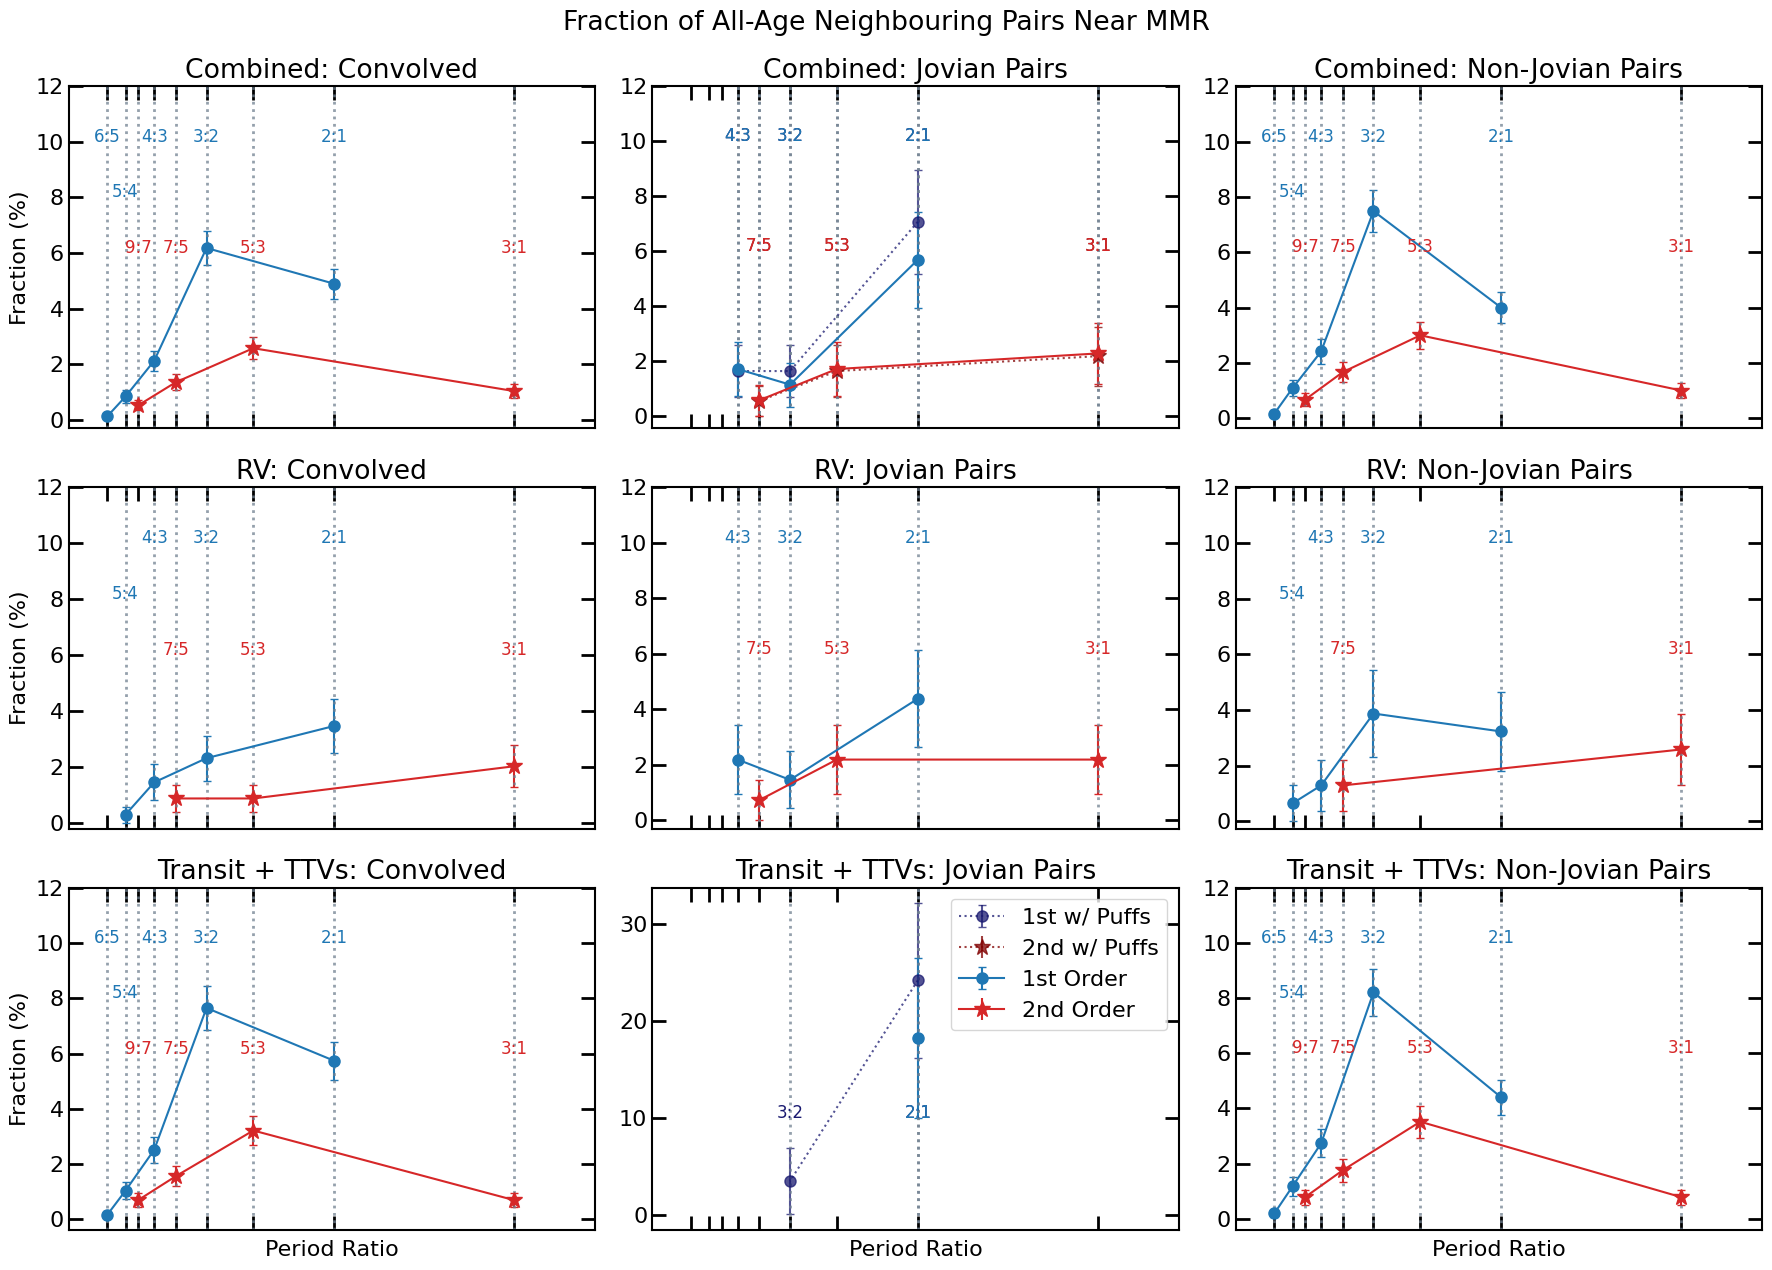

In [13]:
fig, axs = gen.setupPlots((18, 13), row=3, col=3, sharex=True, sharey=False, logscale=2)

for i, mmrdf in enumerate(mmrdfs):
    axs[i][0] = mmrbarMultiWrapper(mmrdf, axs[i][0], yformat=True)
    axs[i][0].set_ylabel('Fraction (%)')
    axs[i][0].set_title(f'{titlelabels[i]}: Convolved')

    if i == 2: yform = False
    else: yform = True
    if not np.all(jm(mmrdf, densepairs) == jm(mmrdf, jovecheck)):
        axs[i][1] = mmrbarMultiWrapper(mmrdf[jm(mmrdf, densepairs)], axs[i][1], yformat=yform, o1dict=puff1st, o2dict=puff2nd)
    axs[i][1] = mmrbarMultiWrapper(mmrdf[jm(mmrdf, jovecheck)], axs[i][1], yformat=yform)
    axs[i][1].set_title(f'{titlelabels[i]}: Jovian Pairs')
    axs[i][2] = mmrbarMultiWrapper(mmrdf[mmrdf.joveflag == '0-0'], axs[i][2])
    axs[i][2].set_title(f'{titlelabels[i]}: Non-Jovian Pairs')

for ax in axs[-1]: ax.set_xlabel('Period Ratio')
axs[2][1].legend()
fig.suptitle('Fraction of All-Age Neighbouring Pairs Near MMR')
fig.tight_layout()
fig.show()